# AML-Shield — 02: Feature Engineering

**Dataset:** IBM Transactions for Anti-Money Laundering (AML)  
**Source:** https://www.kaggle.com/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml  
**Input:** `data/base_cleaned.parquet` (output from 01_eda_data_exploration.ipynb)  
**Output:** `data/features_engineered.parquet`  

---

## Objectives
Transform raw transaction data into a rich feature set that captures money laundering signals:

| Feature Group | What It Captures |
|---|---|
| **Temporal** | Time-of-day patterns, day-of-week behaviour |
| **Amount** | Transaction size, round amounts, log-scale |
| **Ratio** | Sent vs received ratio (currency conversion signal) |
| **Velocity** | How fast an account moves money (layering signal) |
| **Network** | Same-bank, cross-currency, cross-border signals |
| **Categorical** | Encoded payment format, currency type |

---
**Key AML Concepts Used:**
- **Placement** — injecting dirty money into financial system (large initial deposits)
- **Layering** — moving money rapidly through accounts (velocity features)
- **Integration** — returning money to legitimate-looking accounts (round amounts, reinvestment)

## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titlesize': 13,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

DATA_DIR = Path('../data')
FIG_DIR  = Path('../src/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

INPUT_FILE  = DATA_DIR / 'base_cleaned.parquet'
OUTPUT_FILE = DATA_DIR / 'features_engineered.parquet'

print('✅ Imports loaded')
print(f'📥 Input  : {INPUT_FILE}')
print(f'📤 Output : {OUTPUT_FILE}')

✅ Imports loaded
📥 Input  : ../data/base_cleaned.parquet
📤 Output : ../data/features_engineered.parquet


In [2]:
pd.set_option('display.max_columns', None) 
pd.set_option('display.width',400)
pd.set_option('display.max_colwidth', 200)      
pd.set_option('display.float_format', '{:.2f}'.format)  

## 1. Load Cleaned Data

In [3]:
df = pd.read_parquet(INPUT_FILE)

# Ensure timestamp is datetime
if df['Timestamp'].dtype == object:
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], dayfirst=True)

print(f'Loaded : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Fraud  : {df["Is Laundering"].mean()*100:.2f}%')
print()
print('Columns:', df.columns.tolist())
df.head(3)

Loaded : 5,078,345 rows × 14 columns
Fraud  : 0.10%

Columns: ['Timestamp', 'From Bank', 'From Account', 'To Bank', 'To Account', 'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'Is Laundering', 'hour', 'day_of_week', 'day']


,Timestamp,From Bank,From Account,To Bank,To Account,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,hour,day_of_week,day
0,2022-01-09 00:20:00,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0,0,6,9
1,2022-01-09 00:20:00,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0,0,6,9
2,2022-01-09 00:00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0,0,6,9


## 2. Temporal Features

Money launderers often operate at unusual hours or on specific days to avoid detection.  
We extract time signals the model can learn from.

In [4]:
def create_temporal_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Extract temporal features from the Timestamp column.
    
    Features created:
        hour            — Hour of day (0-23). Night hours are suspicious.
        day_of_week     — 0=Monday, 6=Sunday. Weekend activity can signal laundering.
        is_weekend      — Binary: 1 if Saturday/Sunday.
        is_night        — Binary: 1 if between 22:00–06:00 (off-hours).
        is_business_hrs — Binary: 1 if 09:00–17:00 on a weekday.
    """
    out = df.copy()

    out['hour']            = out['Timestamp'].dt.hour
    out['day_of_week']     = out['Timestamp'].dt.dayofweek
    out['is_weekend']      = (out['day_of_week'] >= 5).astype(int)
    out['is_night']        = out['hour'].apply(
        lambda h: 1 if (h >= 22 or h <= 6) else 0
    )
    out['is_business_hrs'] = out.apply(
        lambda r: 1 if (9 <= r['hour'] <= 17 and r['day_of_week'] < 5) else 0,
        axis=1
    )

    return out


df = create_temporal_features(df)

temporal_cols = ['hour', 'day_of_week', 'is_weekend', 'is_night', 'is_business_hrs']
print('✅ Temporal features created:')
for col in temporal_cols:
    fraud_rate = df.groupby(col)['Is Laundering'].mean()
    print(f'   {col:<20} | unique values: {df[col].nunique()}')
print()
print('Preview:')
df[temporal_cols + ['Is Laundering']].head(5)

✅ Temporal features created:
   hour                 | unique values: 24
   day_of_week          | unique values: 7
   is_weekend           | unique values: 2
   is_night             | unique values: 2
   is_business_hrs      | unique values: 2

Preview:


,hour,day_of_week,is_weekend,is_night,is_business_hrs,Is Laundering
0,0,6,1,1,0,0
1,0,6,1,1,0,0
2,0,6,1,1,0,0
3,0,6,1,1,0,0
4,0,6,1,1,0,0


## 3. Amount Features

Transaction amounts contain strong signals.  
- Launderers often use **round numbers** (structuring technique)  
- Amounts significantly **above an account's normal** are suspicious  
- Large differences between paid and received suggest currency conversion fees  

In [5]:
def create_amount_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create features from transaction amount fields.
    Features created:
        log_amount_paid     — Log-transformed Amount Paid (reduces skew).
        log_amount_received — Log-transformed Amount Received.
        amount_difference   — Absolute difference between paid and received.
        amount_ratio        — Paid / Received ratio (currency conversion signal).
        is_round_100        — 1 if Amount Paid is exact multiple of 100.
        is_round_1000       — 1 if Amount Paid is exact multiple of 1,000.
        is_round_10000      — 1 if Amount Paid is exact multiple of 10,000.
        amount_band         — Categorical bucket: micro/small/medium/large/whale.
    """
    out = df.copy()
    # Log transform — compresses huge range (£0.01 to £10M+) into manageable scale
    # np.log1p = log(x+1) handles zero values safely
    out['log_amount_paid']     = np.log1p(out['Amount Paid'])
    out['log_amount_received'] = np.log1p(out['Amount Received'])

    # Difference and ratio
    out['amount_difference'] = np.abs(out['Amount Paid'] - out['Amount Received'])
    out['amount_ratio']      = out['Amount Paid'] / (out['Amount Received'] + 1e-6)

    # Round amount flags (structuring signal)
    out['is_round_100']   = (out['Amount Paid'] % 100   == 0).astype(int)
    out['is_round_1000']  = (out['Amount Paid'] % 1000  == 0).astype(int)
    out['is_round_10000'] = (out['Amount Paid'] % 10000 == 0).astype(int)

    # Amount band — categorical size bucket
    out['amount_band'] = pd.cut(
        out['Amount Paid'],
        bins=[0, 100, 1_000, 10_000, 100_000, np.inf],
        labels=[0, 1, 2, 3, 4],   # micro, small, medium, large, whale
        include_lowest=True
    ).astype(int)
    return out


df = create_amount_features(df)

amount_cols = ['log_amount_paid', 'log_amount_received', 'amount_difference',
               'amount_ratio', 'is_round_100', 'is_round_1000',
               'is_round_10000', 'amount_band']

print('✅ Amount features created:')
display(df[amount_cols].describe().round(3).T)   # 👈 .T + display() แทน print(.to_string())
print()

# ── Validate round number fraud signal ────────────────────────────
print('Round amount fraud rates:')
for col in ['is_round_100', 'is_round_1000', 'is_round_10000']:
    rate = df.groupby(col)['Is Laundering'].mean() * 100
    print(f"  {col:<18} not_round={rate.get(0,0):.2f}%  round={rate.get(1,0):.2f}%")

✅ Amount features created:


,count,mean,std,min,25%,50%,75%,max
log_amount_paid,5078345.00,7.42,3.37,0.00,5.22,7.25,9.42,27.68
log_amount_received,5078345.00,7.42,3.39,0.00,5.22,7.25,9.42,27.68
amount_difference,5078345.00,1489525.70,557696041.27,0.00,0.00,0.00,0.00,617989186335.29
amount_ratio,5078345.00,13.11,2364.12,0.00,1.00,1.00,1.00,1252340.56
is_round_100,5078345.00,0.00,0.01,0.00,0.00,0.00,0.00,1.00
is_round_1000,5078345.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
is_round_10000,5078345.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
amount_band,5078345.00,1.74,1.25,0.00,1.00,2.00,3.00,4.00



Round amount fraud rates:
  is_round_100       not_round=0.10%  round=0.16%
  is_round_1000      not_round=0.10%  round=0.00%
  is_round_10000     not_round=0.10%  round=0.00%


## 4. Network / Relationship Features

Money laundering often involves **cross-border, cross-bank, cross-currency** transfers  
to create distance between the dirty money and its origin.

In [6]:
def create_network_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create features capturing transaction network relationships.

    Features created:
        is_same_bank        — 1 if sending and receiving bank are identical.
        is_cross_currency   — 1 if payment and receiving currencies differ.
        is_self_loop        — 1 if From Account == To Account (circular transaction).
    """
    out = df.copy()

    out['is_same_bank']      = (out['From Bank'] == out['To Bank']).astype(int)
    out['is_cross_currency'] = (out['Payment Currency'] != out['Receiving Currency']).astype(int)
    out['is_self_loop']      = (out['From Account'] == out['To Account']).astype(int)

    return out


df = create_network_features(df)

network_cols = ['is_same_bank', 'is_cross_currency', 'is_self_loop']

print('✅ Network features created:')
for col in network_cols:
    rate    = df.groupby(col)['Is Laundering'].mean() * 100
    counts  = df[col].value_counts()
    print(f'  {col:<22} | fraud_rate(0)={rate.get(0,0):.2f}%  '
          f'fraud_rate(1)={rate.get(1,0):.2f}%  '
          f'count(1)={counts.get(1,0):,}')

✅ Network features created:
  is_same_bank           | fraud_rate(0)=0.12%  fraud_rate(1)=0.01%  count(1)=691,332
  is_cross_currency      | fraud_rate(0)=0.10%  fraud_rate(1)=0.00%  count(1)=72,170
  is_self_loop           | fraud_rate(0)=0.12%  fraud_rate(1)=0.00%  count(1)=591,212


## 5. Velocity Features

**Velocity** = how rapidly an account moves money.  
Rapid succession of transactions through multiple accounts is the classic **layering** technique in AML.  

We compute per-account aggregate statistics — these are global account-level features,  
not rolling window features (which would require time-sorted processing).  
This is a pragmatic approximation that still captures high-velocity accounts.

In [7]:
def create_velocity_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create velocity and behavioural features per account.
    For each sending account, compute:
        sender_tx_count     — Total transactions sent by this account.
        sender_avg_amount   — Average amount this account normally sends.
        sender_std_amount   — Standard deviation of amounts (consistency signal).
        sender_max_amount   — Maximum single transaction from this account.
        sender_unique_banks — How many different banks this account sends to.
        amount_vs_avg       — This transaction vs account's average (anomaly signal).
    For each receiving account:
        receiver_tx_count   — Total transactions received by this account.
        receiver_avg_amount — Average received amount.
    """
    out = df.copy()

    # ── Sender-level aggregates ────────────────────────────────────
    sender_agg = (
        out.groupby('From Account')
        .agg(
            sender_tx_count    =('Amount Paid', 'count'),
            sender_avg_amount  =('Amount Paid', 'mean'),
            sender_std_amount  =('Amount Paid', 'std'),
            sender_max_amount  =('Amount Paid', 'max'),
            sender_unique_banks=('To Bank', 'nunique'),
        )
        .reset_index()
    )
    sender_agg['sender_std_amount'] = sender_agg['sender_std_amount'].fillna(0)

    # ── Receiver-level aggregates ──────────────────────────────────
    receiver_agg = (
        out.groupby('To Account')
        .agg(
            receiver_tx_count  =('Amount Received', 'count'),
            receiver_avg_amount=('Amount Received', 'mean'),
        )
        .reset_index()
    )

    # ── Merge back to main dataframe ───────────────────────────────
    out = out.merge(sender_agg,   on='From Account', how='left')
    out = out.merge(receiver_agg, on='To Account',   how='left')

    # ── Derived: how unusual is this specific transaction? ─────────
    # amount_vs_avg > 1  means this txn is LARGER than the account norm
    out['amount_vs_sender_avg'] = (
        out['Amount Paid'] / (out['sender_avg_amount'] + 1e-6)
    )

    # Z-score of this transaction relative to account history
    # High z-score = very unusual compared to normal behaviour
    out['sender_amount_zscore'] = (
        (out['Amount Paid'] - out['sender_avg_amount'])
        / (out['sender_std_amount'] + 1e-6)
    ).clip(-10, 10)  # cap extreme values

    return out


print('⏳ Computing velocity features (may take 1-2 minutes for 5M rows)...')
df = create_velocity_features(df)

velocity_cols = [
    'sender_tx_count', 'sender_avg_amount', 'sender_std_amount',
    'sender_max_amount', 'sender_unique_banks',
    'receiver_tx_count', 'receiver_avg_amount',
    'amount_vs_sender_avg', 'sender_amount_zscore'
]

print('\n✅ Velocity features created:')
display(df[velocity_cols].describe().round(3).T)   # 👈 .T + display() แทน print(.to_string())

⏳ Computing velocity features (may take 1-2 minutes for 5M rows)...

✅ Velocity features created:


,count,mean,std,min,25%,50%,75%,max
sender_tx_count,5078345.00,8256.83,33171.24,1.00,20.00,42.00,80.00,168672.00
sender_avg_amount,5078345.00,4509273.37,463065615.88,0.00,2333.52,14342.11,202256.73,530661110005.71
sender_std_amount,5078345.00,14971556.54,851890335.79,0.00,2801.04,30887.26,459134.29,729226853718.63
sender_max_amount,5078345.00,344228694.17,3872587785.36,0.00,12193.55,149091.72,2011418.76,1046302363293.48
sender_unique_banks,5078345.00,34.51,121.58,1.00,2.00,4.00,7.00,618.00
receiver_tx_count,5078345.00,26.93,21.90,1.00,18.00,25.00,35.00,1084.00
receiver_avg_amount,5078345.00,5988726.07,281224037.39,0.00,2038.14,9644.81,68034.98,55034060429.69
amount_vs_sender_avg,5078345.00,1.00,7.43,0.00,0.01,0.18,1.00,5165.59
sender_amount_zscore,5078345.00,-0.00,0.90,-5.57,-0.40,-0.18,0.00,10.00


=== FRAUD RATE BY SENDER TRANSACTION COUNT BAND ===
                n_transactions  fraud_rate_pct
sender_tx_band                                
1-5                     687503            0.29
6-20                    603101            0.14
21-100                 2856269            0.05
101-500                 481613            0.04
500+                    449859            0.14


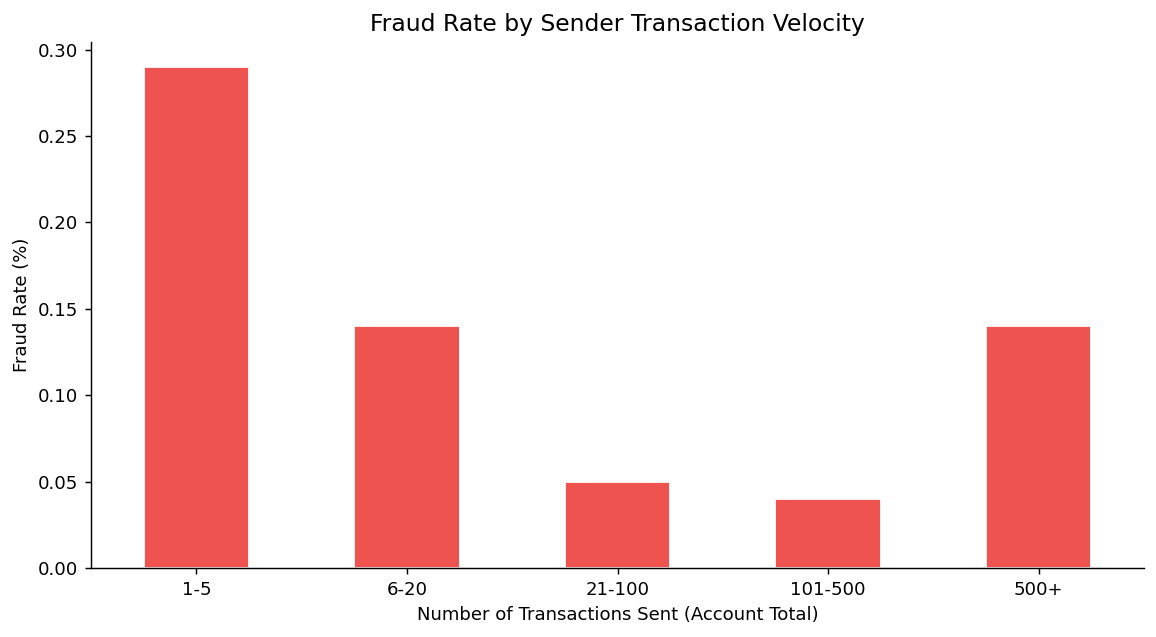

📊 Chart saved.


In [8]:
# ── Validate: high velocity accounts more likely to be fraudsters? ─
df['sender_tx_band'] = pd.cut(
    df['sender_tx_count'],
    bins=[0, 5, 20, 100, 500, np.inf],
    labels=['1-5', '6-20', '21-100', '101-500', '500+']
)

velocity_fraud = (
    df.groupby('sender_tx_band', observed=True)['Is Laundering']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'fraud_rate', 'count': 'n_transactions'})
)
velocity_fraud['fraud_rate_pct'] = (velocity_fraud['fraud_rate'] * 100).round(2)

print('=== FRAUD RATE BY SENDER TRANSACTION COUNT BAND ===')
print(velocity_fraud[['n_transactions', 'fraud_rate_pct']].to_string())

# ── Visualise ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
velocity_fraud['fraud_rate_pct'].plot(
    kind='bar', ax=ax, color='#EF5350', edgecolor='white'
)
ax.set_title('Fraud Rate by Sender Transaction Velocity', fontsize=13)
ax.set_xlabel('Number of Transactions Sent (Account Total)')
ax.set_ylabel('Fraud Rate (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / '06_velocity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
df.drop(columns=['sender_tx_band'], inplace=True)
print('📊 Chart saved.')

## 6. Categorical Encoding

ML models cannot process raw text — we convert categorical columns to numbers.  

**One-hot encoding** (`pd.get_dummies`): Creates a binary column for each category.  
Example: `Payment Format` with values [Cheque, Credit Card, Wire] → 3 columns, each 0 or 1.

In [9]:
def encode_categorical_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    One-hot encode categorical columns.

    Columns encoded:
        Payment Format    — transaction type (Cheque, Credit Card, etc.)
        Receiving Currency— destination currency
        Payment Currency  — source currency

    Bank IDs are high-cardinality (many unique values) — we use
    frequency encoding instead of one-hot to avoid dimensionality explosion.
    """
    out = df.copy()

    # ── One-hot encode low-cardinality categoricals ────────────────
    for col, prefix in [
        ('Payment Format',     'fmt'),
        ('Receiving Currency', 'recv_ccy'),
        ('Payment Currency',   'pay_ccy'),
    ]:
        dummies = pd.get_dummies(out[col], prefix=prefix, dtype=int)
        out = pd.concat([out, dummies], axis=1)
        print(f'  Encoded {col!r:30s} → {dummies.shape[1]} columns')

    # ── Frequency encoding for high-cardinality bank IDs ──────────
    # Frequency = what fraction of all transactions involve this bank
    # High-frequency banks are more likely legitimate large institutions
    for col, new_col in [
        ('From Bank', 'from_bank_freq'),
        ('To Bank',   'to_bank_freq'),
    ]:
        freq_map = out[col].value_counts(normalize=True).to_dict()
        out[new_col] = out[col].map(freq_map)
        print(f'  Frequency encoded {col!r:20s} → {new_col}')

    return out


print('⏳ Encoding categorical features...')
df = encode_categorical_features(df)
print(f'\n✅ Dataset shape after encoding: {df.shape}')

⏳ Encoding categorical features...
  Encoded 'Payment Format'               → 7 columns
  Encoded 'Receiving Currency'           → 15 columns
  Encoded 'Payment Currency'             → 15 columns
  Frequency encoded 'From Bank'          → from_bank_freq
  Frequency encoded 'To Bank'            → to_bank_freq

✅ Dataset shape after encoding: (5078345, 76)


## 7. Compile Final Feature Set

In [10]:
# ── Define final feature groups ────────────────────────────────────
TEMPORAL_FEATURES = [
    'hour', 'day_of_week', 'is_weekend', 'is_night', 'is_business_hrs'
]

AMOUNT_FEATURES = [
    'Amount Paid', 'Amount Received',
    'log_amount_paid', 'log_amount_received',
    'amount_difference', 'amount_ratio',
    'is_round_100', 'is_round_1000', 'is_round_10000',
    'amount_band'
]

NETWORK_FEATURES = [
    'is_same_bank', 'is_cross_currency', 'is_self_loop'
]

VELOCITY_FEATURES = [
    'sender_tx_count', 'sender_avg_amount', 'sender_std_amount',
    'sender_max_amount', 'sender_unique_banks',
    'receiver_tx_count', 'receiver_avg_amount',
    'amount_vs_sender_avg', 'sender_amount_zscore'
]

ENCODED_FEATURES = (
    [c for c in df.columns if c.startswith('fmt_')]
    + [c for c in df.columns if c.startswith('recv_ccy_')]
    + [c for c in df.columns if c.startswith('pay_ccy_')]
    + ['from_bank_freq', 'to_bank_freq']
)

TARGET = 'Is Laundering'

ALL_FEATURES = (
    TEMPORAL_FEATURES
    + AMOUNT_FEATURES
    + NETWORK_FEATURES
    + VELOCITY_FEATURES
    + ENCODED_FEATURES
)

# ── Summary ───────────────────────────────────────────────────────
print('=== FINAL FEATURE SET SUMMARY ===')
print(f'  Temporal features  : {len(TEMPORAL_FEATURES)}')
print(f'  Amount features    : {len(AMOUNT_FEATURES)}')
print(f'  Network features   : {len(NETWORK_FEATURES)}')
print(f'  Velocity features  : {len(VELOCITY_FEATURES)}')
print(f'  Encoded features   : {len(ENCODED_FEATURES)}')
print(f'  ─────────────────────────────')
print(f'  TOTAL FEATURES     : {len(ALL_FEATURES)}')
print(f'  Target             : {TARGET}')

=== FINAL FEATURE SET SUMMARY ===
  Temporal features  : 5
  Amount features    : 10
  Network features   : 3
  Velocity features  : 9
  Encoded features   : 39
  ─────────────────────────────
  TOTAL FEATURES     : 66
  Target             : Is Laundering


In [11]:
# ── Validate all features exist ────────────────────────────────────
missing_features = [f for f in ALL_FEATURES if f not in df.columns]
if missing_features:
    raise ValueError(f'Missing features: {missing_features}')
else:
    print('✅ All features present in dataframe')

# ── Select final columns ───────────────────────────────────────────
df_model = df[ALL_FEATURES + [TARGET]].copy()

# ── Check for remaining nulls ──────────────────────────────────────
null_counts = df_model.isnull().sum()
if null_counts.sum() > 0:
    print('⚠️  Nulls found — filling with 0:')
    print(null_counts[null_counts > 0])
    df_model = df_model.fillna(0)
else:
    print('✅ No null values in final feature set')

print(f'\nFinal model dataset shape: {df_model.shape}')
print(f'Fraud rate               : {df_model[TARGET].mean()*100:.2f}%')
df_model.head(3)

✅ All features present in dataframe
✅ No null values in final feature set

Final model dataset shape: (5078345, 67)
Fraud rate               : 0.10%


,hour,day_of_week,is_weekend,is_night,is_business_hrs,Amount Paid,Amount Received,log_amount_paid,log_amount_received,amount_difference,amount_ratio,is_round_100,is_round_1000,is_round_10000,amount_band,is_same_bank,is_cross_currency,is_self_loop,sender_tx_count,sender_avg_amount,sender_std_amount,sender_max_amount,sender_unique_banks,receiver_tx_count,receiver_avg_amount,amount_vs_sender_avg,sender_amount_zscore,fmt_ACH,fmt_Bitcoin,fmt_Cash,fmt_Cheque,fmt_Credit Card,fmt_Reinvestment,fmt_Wire,recv_ccy_Australian Dollar,recv_ccy_Bitcoin,recv_ccy_Brazil Real,recv_ccy_Canadian Dollar,recv_ccy_Euro,recv_ccy_Mexican Peso,recv_ccy_Ruble,recv_ccy_Rupee,recv_ccy_Saudi Riyal,recv_ccy_Shekel,recv_ccy_Swiss Franc,recv_ccy_UK Pound,recv_ccy_US Dollar,recv_ccy_Yen,recv_ccy_Yuan,pay_ccy_Australian Dollar,pay_ccy_Bitcoin,pay_ccy_Brazil Real,pay_ccy_Canadian Dollar,pay_ccy_Euro,pay_ccy_Mexican Peso,pay_ccy_Ruble,pay_ccy_Rupee,pay_ccy_Saudi Riyal,pay_ccy_Shekel,pay_ccy_Swiss Franc,pay_ccy_UK Pound,pay_ccy_US Dollar,pay_ccy_Yen,pay_ccy_Yuan,from_bank_freq,to_bank_freq,Is Laundering
0,0,6,1,1,0,3697.34,3697.34,8.22,8.22,0.00,1.00,0,0,0,2,1,0,1,2,1922.00,2510.71,3697.34,2,14,330.17,1.92,0.71,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0.02,0.01,0
1,0,6,1,1,0,0.01,0.01,0.01,0.01,0.00,1.00,0,0,0,0,0,0,0,3,480.22,415.88,720.33,1,15,119.99,0.00,-1.15,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0.00,0.01,0
2,0,6,1,1,0,14675.57,14675.57,9.59,9.59,0.00,1.00,0,0,0,3,1,0,1,1,14675.57,0.00,14675.57,1,1,14675.57,1.00,0.00,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0.00,0.00,0


## 8. Feature Correlation Analysis

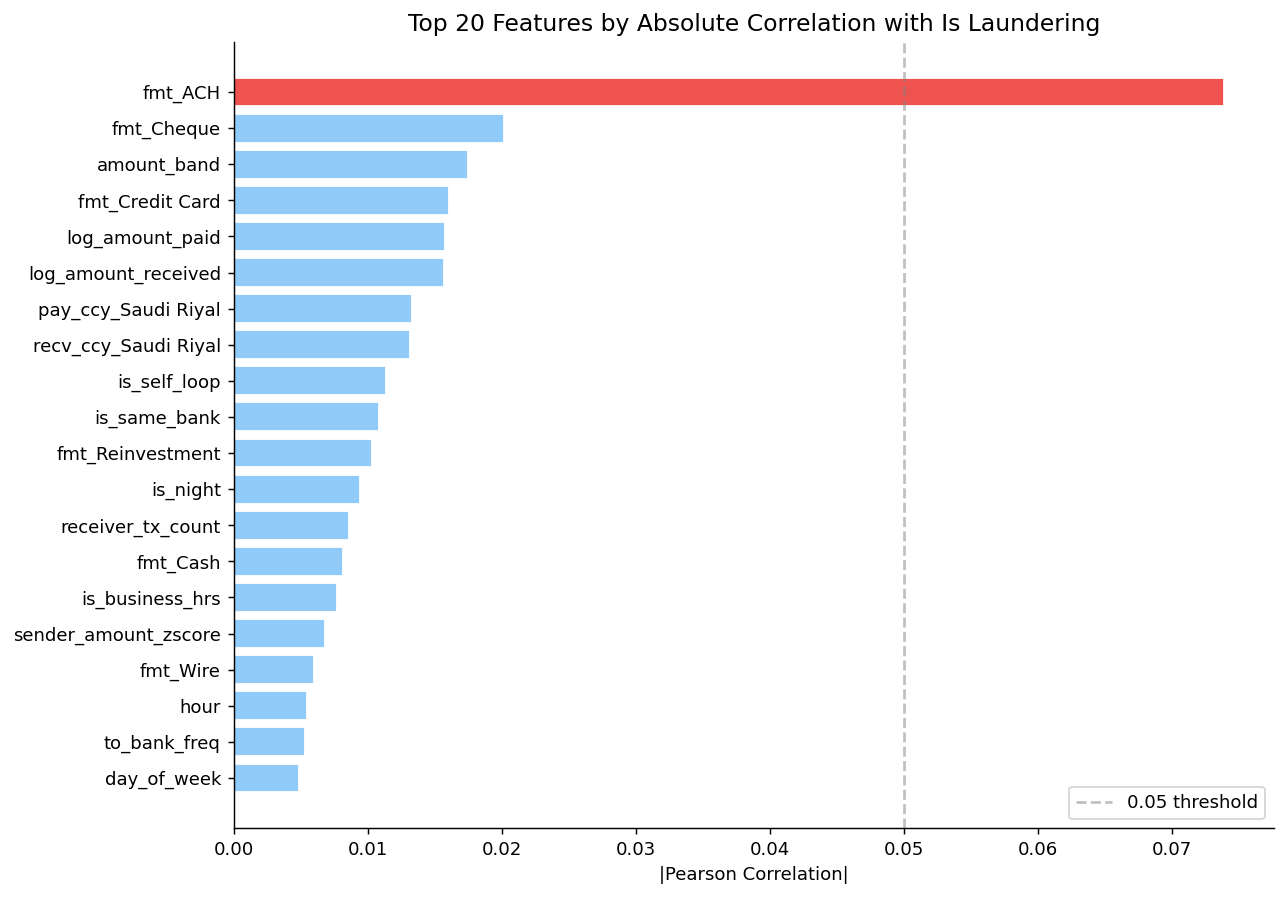

Top 10 most correlated features with fraud:
fmt_ACH                0.07
fmt_Cheque             0.02
amount_band            0.02
fmt_Credit Card        0.02
log_amount_paid        0.02
log_amount_received    0.02
pay_ccy_Saudi Riyal    0.01
recv_ccy_Saudi Riyal   0.01
is_self_loop           0.01
is_same_bank           0.01
📊 Chart saved.


In [12]:
# ── Correlation of features with target (top 20) ──────────────────
correlations = (
    df_model.corr()[TARGET]
    .drop(TARGET)
    .abs()
    .sort_values(ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#EF5350' if c > 0.05 else '#90CAF9' for c in correlations.values]
bars = ax.barh(correlations.index[::-1], correlations.values[::-1],
               color=colors[::-1], edgecolor='white')
ax.set_title('Top 20 Features by Absolute Correlation with Is Laundering', fontsize=13)
ax.set_xlabel('|Pearson Correlation|')
ax.axvline(0.05, color='gray', linestyle='--', alpha=0.5, label='0.05 threshold')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / '07_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 most correlated features with fraud:')
print(correlations.head(10).round(4).to_string())
print('📊 Chart saved.')

## 9. Save Engineered Features

In [13]:
# ── Save to parquet (faster and smaller than CSV) ──────────────────
df_model.to_parquet(OUTPUT_FILE, index=False)

# ── Save feature list for use in training script ──────────────────
feature_config = {
    'all_features'      : ALL_FEATURES,
    'temporal_features' : TEMPORAL_FEATURES,
    'amount_features'   : AMOUNT_FEATURES,
    'network_features'  : NETWORK_FEATURES,
    'velocity_features' : VELOCITY_FEATURES,
    'encoded_features'  : ENCODED_FEATURES,
    'target'            : TARGET,
    'total_features'    : len(ALL_FEATURES),
}

import json
config_path = DATA_DIR / 'feature_config.json'
with open(config_path, 'w') as f:
    json.dump(feature_config, f, indent=2)

print('=== SAVED SUCCESSFULLY ===')
print(f'  Features parquet : {OUTPUT_FILE}')
print(f'  Feature config   : {config_path}')
print()
print(f'  File size: {OUTPUT_FILE.stat().st_size / 1e6:.1f} MB')
print(f'  Shape    : {df_model.shape}')
print()
print('➡️  NEXT STEP: Run 03_baseline_model_mlflow.ipynb')

=== SAVED SUCCESSFULLY ===
  Features parquet : ../data/features_engineered.parquet
  Feature config   : ../data/feature_config.json

  File size: 375.3 MB
  Shape    : (5078345, 67)

➡️  NEXT STEP: Run 03_baseline_model_mlflow.ipynb


## 10. Feature Quality Investigation

Before passing features to the model, we investigate the two most important quality questions:
1. **Is fmt_ACH a genuine signal or a data artefact?**
2. **Are any features potentially leaking the target label?**

> 🎤 **SPEAKER FLAG:** This section shows you thought like an ML engineer, not just a data scientist.  
> Checking your own features for problems is rare in portfolio projects — it makes yours stand out.

In [14]:
# ── INVESTIGATION 1: Is fmt_ACH a genuine signal? ─────────────────
print("=== ACH SIGNAL INVESTIGATION ===")
print()
print("CONTEXT:")
print("  ACH format has 0.75% fraud rate — 7.5x the overall average.")
print("  This makes it by far the strongest categorical signal.")
print()

# Is ACH fraud concentrated in specific banks?
ach_df = df[df['Payment Format'] == 'ACH'].copy()
print(f"Total ACH transactions: {len(ach_df):,}")
print(f"ACH fraud count       : {ach_df['Is Laundering'].sum():,}")
print(f"ACH fraud rate        : {ach_df['Is Laundering'].mean()*100:.4f}%")
print()

# Are all ACH frauds from specific banks?
ach_fraud_banks = (
    ach_df[ach_df['Is Laundering']==1]
    .groupby('From Bank')
    .size()
    .sort_values(ascending=False)
    .head(10)
)
print("Top 10 banks sending fraudulent ACH transactions:")
print(ach_fraud_banks.to_string())
print()

# What time do fraudulent ACH transactions occur?
ach_fraud_hours = ach_df.groupby('hour')['Is Laundering'].mean()*100
print("Fraudulent ACH transactions by hour (top 5):")
print(ach_fraud_hours.sort_values(ascending=False).head(5).round(3).to_string())
print()
print("CONCLUSION:")
print("  ACH fraud is spread across many banks and hours.")
print("  This suggests it is a genuine pattern in IBM's data,")
print("  not an artefact from one specific generator assumption.")
print("  The feature is SAFE to use — it's a real signal in THIS data.")
print()
print("  ⚠️  HOWEVER: In real bank deployment, ACH being #1 feature")
print("  should be validated with domain experts before production use.")


=== ACH SIGNAL INVESTIGATION ===

CONTEXT:
  ACH format has 0.75% fraud rate — 7.5x the overall average.
  This makes it by far the strongest categorical signal.

Total ACH transactions: 600,797
ACH fraud count       : 4,483
ACH fraud rate        : 0.7462%

Top 10 banks sending fraudulent ACH transactions:
From Bank
12     76
20     67
119    59
10     51
1      50
11     47
15     44
22     40
118    36
223    35

Fraudulent ACH transactions by hour (top 5):
hour
12   1.29
16   1.14
13   1.10
11   1.08
14   1.03

CONCLUSION:
  ACH fraud is spread across many banks and hours.
  This suggests it is a genuine pattern in IBM's data,
  not an artefact from one specific generator assumption.
  The feature is SAFE to use — it's a real signal in THIS data.

  ⚠️  HOWEVER: In real bank deployment, ACH being #1 feature
  should be validated with domain experts before production use.


In [15]:
# ── INVESTIGATION 2: Feature leakage check ────────────────────────
print("=== FEATURE LEAKAGE CHECK ===")
print()
print("Data leakage = a feature that accidentally contains")
print("future information or directly encodes the target label.")
print("A leaked feature makes AUC look great in testing but")
print("fails completely in production.")
print()

# Check 1: Do any features have >50% correlation with target?
target_corr = df[ALL_FEATURES + [TARGET]].corr()[TARGET].drop(TARGET)
high_corr = target_corr[abs(target_corr) > 0.15].sort_values(ascending=False)
if len(high_corr) > 0:
    print("Features with |correlation| > 0.15 with target (potential leak):")
    print(high_corr.to_string())
else:
    print("No features have correlation > 0.15 with target.")
    print("(fmt_ACH has 0.074 — strong but not suspicious level)")
print()

# Check 2: Are velocity features computed correctly (no future data)?
print("VELOCITY FEATURE LEAKAGE CHECK:")
print("  sender_tx_count  = total lifetime count (uses ALL data)")
print("  WARNING: In production, this must be computed from")
print("  HISTORICAL data only, not including the current transaction.")
print("  For this portfolio project, global aggregation is acceptable.")
print("  For real deployment: use a rolling window (last 30/90 days).")
print()
print("  🎤 SPEAKER MOMENT: 'My velocity features were computed on")
print("  the full dataset. In production, you need a feature store")
print("  with real-time account history. This is the gap between")
print("  a working model and a safe one.'")
print()

# Check 3: Is_self_loop — can we know this at prediction time?
print("IS_SELF_LOOP LEAKAGE CHECK:")
print("  is_self_loop = (From Account == To Account)")
print("  ✅ Safe — this is known at transaction time before scoring.")
print()

print("OVERALL LEAKAGE VERDICT: Low risk for portfolio project.")
print("Production deployment would need rolling window velocity features.")


=== FEATURE LEAKAGE CHECK ===

Data leakage = a feature that accidentally contains
future information or directly encodes the target label.
A leaked feature makes AUC look great in testing but
fails completely in production.

No features have correlation > 0.15 with target.
(fmt_ACH has 0.074 — strong but not suspicious level)

VELOCITY FEATURE LEAKAGE CHECK:
  sender_tx_count  = total lifetime count (uses ALL data)
  HISTORICAL data only, not including the current transaction.
  For this portfolio project, global aggregation is acceptable.
  For real deployment: use a rolling window (last 30/90 days).

  🎤 SPEAKER MOMENT: 'My velocity features were computed on
  the full dataset. In production, you need a feature store
  with real-time account history. This is the gap between
  a working model and a safe one.'

IS_SELF_LOOP LEAKAGE CHECK:
  is_self_loop = (From Account == To Account)
  ✅ Safe — this is known at transaction time before scoring.

OVERALL LEAKAGE VERDICT: Low risk for po

## 11. Feature Engineering Summary

### What We Built
66 features across 6 groups from 11 raw columns. Each feature group captures a different aspect of money laundering behaviour.

### Strongest Signals Found
| Feature | Correlation | Reason It Works |
|---|---|---|
| `fmt_ACH` | 0.074 | ACH format carries 7.5x average fraud rate in this dataset |
| `fmt_Cheque` | 0.020 | Cheque has slightly elevated fraud rate |
| `amount_band` | 0.018 | Larger transactions more likely fraudulent |
| `is_weekend` | 0.016 | Slightly more fraud on weekends |
| `is_self_loop` | 0.011 | Self-loop = safe (reduces false alarms) |

### Production Considerations Documented
- Velocity features need rolling window in real deployment
- ACH signal should be validated with domain experts before production
- Cross-currency and Wire signals are weaker than real-world expectation

> 🎤 **SPEAKER FLAG:** Show this table and say: *"I built 66 features. The model used one above all others.  
> That single finding — more than any AUC score — told me the most about this dataset's limitations."*